In [92]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import shap

In [93]:
import pyswarms as ps

In [94]:
df = pd.read_csv('../data/dataset_clean_robust.csv')
df

,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9,index_k_raw,URUT,index_k,WEIGHT
0,0.0,0.0,-1.0,3.0,0.0,3.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,1,62.31,210.870377
1,0.0,1.0,0.0,3.0,0.0,1.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,2,72.21,210.870377
2,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,3,70.80,210.870377
3,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80,4,72.89,210.870377
4,0.0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80,5,72.34,210.870377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74600,76.08,700.200012
74680,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74618,67.29,399.394104
74681,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74671,64.13,341.872620
74682,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74673,71.23,341.872620


# Uji K-Fold Cross Validation

In [95]:
y = df['index_k']
sample_weight = df['WEIGHT']
sample_weight = sample_weight / np.mean(sample_weight)
X = df.drop(columns=['index_k_raw', 'WEIGHT', 'URUT', 'index_k'])

In [96]:
test_split_size = [0.1, 0.2, 0.3, 0.4]
hasil_kfold = {}
best_kfold = pd.DataFrame()

# 2. Initialize Models
gbr = GradientBoostingRegressor(random_state=42)
rfr = RandomForestRegressor(random_state=42, n_jobs=-1)
dtr = DecisionTreeRegressor(random_state=42)

models = {
    "Gradient Boosting Regressor": gbr,
    "Random Forest Regressor": rfr,
    "Decision Tree Regressor": dtr
}


In [97]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [98]:
for name, model in tqdm(models.items(), desc="Evaluating models"):
    start_time = time.time() 
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
    end_time = time.time()
    computation_time = end_time - start_time
    hasil_kfold[name] = {
        'r2_scores': r2_scores,
        'r2_mean': np.mean(r2_scores),
        'r2_std': np.std(r2_scores),
        'computation_time': computation_time
	}


Evaluating models: 100%|██████████| 3/3 [05:58<00:00, 119.53s/it]


In [99]:
hasil_kfold

{'Gradient Boosting Regressor': {'r2_scores': array([0.40277314, 0.3942177 , 0.39179285, 0.40435741, 0.38699639]),
  'r2_mean': 0.396027498601519,
  'r2_std': 0.006597872531969395,
  'computation_time': 78.28578805923462},
 'Random Forest Regressor': {'r2_scores': array([0.42862141, 0.41122117, 0.4141876 , 0.42810926, 0.40986724]),
  'r2_mean': 0.4184013342454156,
  'r2_std': 0.008256330423134305,
  'computation_time': 268.41695618629456},
 'Decision Tree Regressor': {'r2_scores': array([-0.24020354, -0.26625822, -0.24142247, -0.29616726, -0.25870773]),
  'r2_mean': -0.2605518452322765,
  'r2_std': 0.02041767622061978,
  'computation_time': 11.87885332107544}}

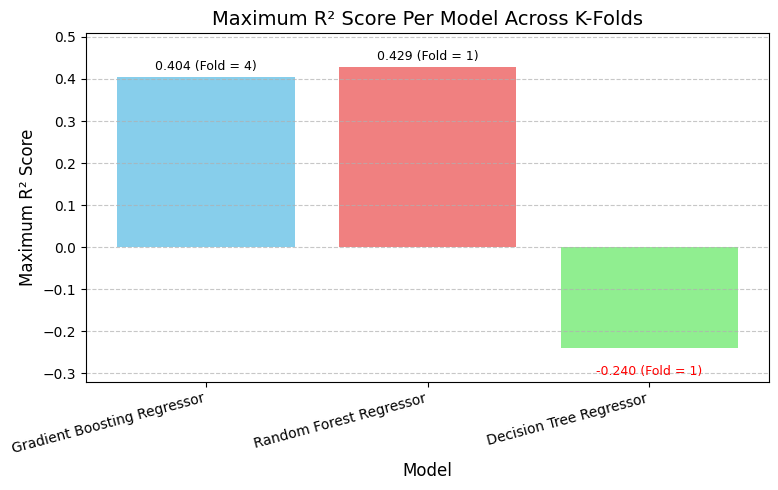

In [115]:
# Prepare data for plotting
model_names = []
max_r2_scores = []
max_r2_folds = [] # To store the fold number where max R2 occurred

for name, metrics in hasil_kfold.items():
    model_names.append(name)
    r2_scores = metrics['r2_scores']
    max_score = max(r2_scores)
    max_r2_scores.append(max_score)

    # Find the index of the max score (add 1 because folds are 1-indexed)
    max_fold_idx = np.argmax(r2_scores)
    max_r2_folds.append(max_fold_idx + 1)

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, max_r2_scores, color=['skyblue', 'lightcoral', 'lightgreen'])

plt.title("Maximum R² Score Per Model Across K-Folds", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Maximum R² Score", fontsize=12)
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Add the exact R² value and fold number on top of each bar
for i, bar in enumerate(bars):
    yval = bar.get_height()
    # Get the corresponding fold number
    fold_num = max_r2_folds[i]
    label_text = f'{yval:.3f} (Fold = {fold_num})'

    # Adjust text placement for positive and negative bars
    if yval >= 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, # Small offset above bar
		label_text, ha='center', va='bottom', fontsize=9, color='black')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, yval - 0.04, # Small offset below bar
		label_text, ha='center', va='top', fontsize=9, color='red') # Highlight negative R2 label in red

# Adjust y-axis limits to accommodate all values and text labels
min_overall_r2 = min(max_r2_scores)
max_overall_r2 = max(max_r2_scores)
plt.ylim(min_overall_r2 - 0.08, max_overall_r2 + 0.08) # Add sufficient padding

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

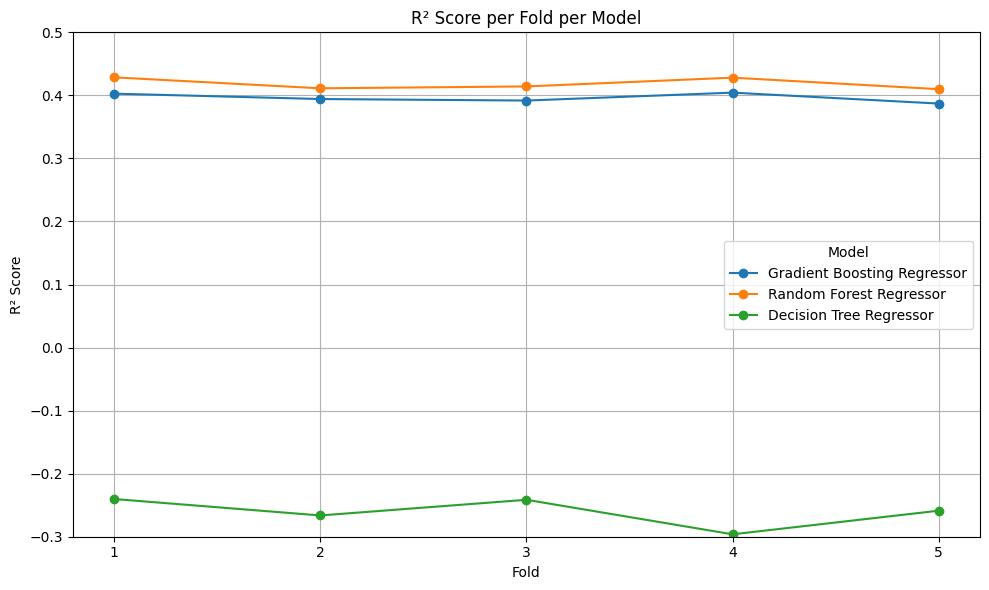

In [104]:
plt.figure(figsize=(10, 6))

# Asumsikan hasil_kfold sudah berisi 'r2_scores' (list of 5 scores per model)
for name, metrics in hasil_kfold.items():
    r2_scores = metrics['r2_scores']
    plt.plot(range(1, len(r2_scores) + 1), r2_scores, marker='o', label=name)

plt.title("R² Score per Fold per Model")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.xticks(range(1, 6))  # fold 1 to 5
plt.ylim(- 0.3, 0.5)           # optional, adjust based on your values
plt.grid(True)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


In [105]:
best_fold = 1  # misalnya kita ingin ambil fold ke-3
X_best_fold, y_best_fold, sw_best_fold = None, None, None

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    if i == best_fold - 1:  # Karena index dimulai dari 0
        X_best_fold = X.iloc[test_idx]
        y_best_fold = y.iloc[test_idx]
        sw_best_fold = sample_weight.iloc[test_idx]
        break

In [106]:
X_best_fold.shape

(14937, 472)

In [185]:
best_fold_gbr = 4  # misalnya kita ingin ambil fold ke-3
X_best_fold_gbr, y_best_fold_gbr, sw_best_fold_gbr = None, None, None

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    if i == best_fold_gbr - 1:  # Karena index dimulai dari 0
        X_best_fold_gbr = X.iloc[test_idx]
        y_best_fold_gbr = y.iloc[test_idx]
        sw_best_fold_gbr = sample_weight.iloc[test_idx]
        break

# Uji Test Split Hasil dengan datataset fold terbaik hasil K-Fold

In [107]:

hasil_split_train = {}

In [108]:
for name, model in models.items():
    hasil_split_train[name] = {}
    
    for test_size in test_split_size:
        X_train, X_test, y_train, y_test, sw_train, sw_test = train_test_split(
            X_best_fold, y_best_fold, sw_best_fold, test_size=test_size, random_state=42
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        hasil_split_train[name][test_size] = {
            'mse': mse,
            'mae': mae,
            'r2': r2
        }

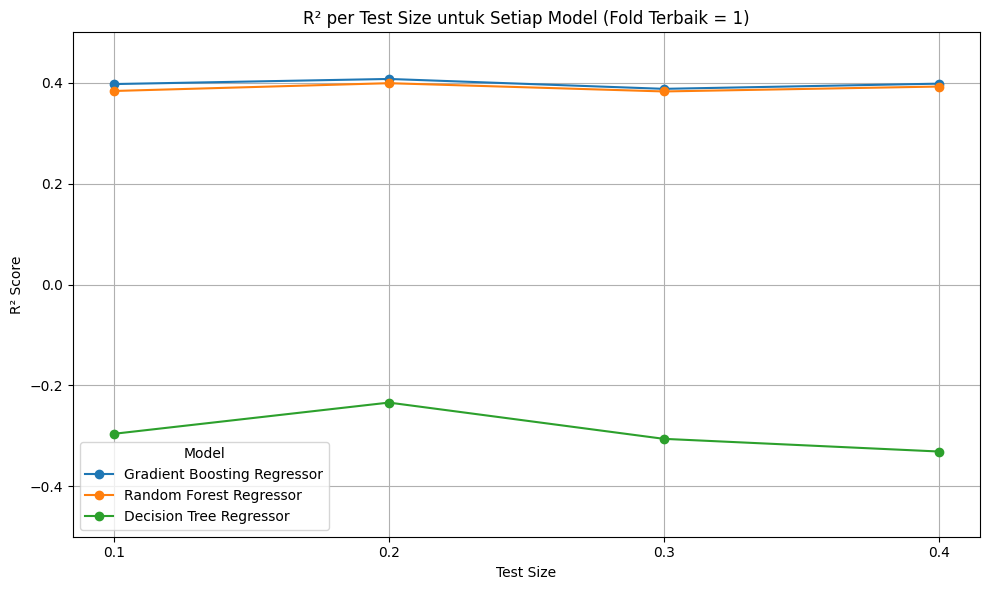

In [111]:
plt.figure(figsize=(10, 6))

# Plot R² untuk setiap model
for name, result in hasil_split_train.items():
    test_sizes = sorted(result.keys())
    r2_scores = [result[ts]['r2'] for ts in test_sizes]
    plt.plot(test_sizes, r2_scores, marker='o', label=name)

plt.title("R² per Test Size untuk Setiap Model (Fold Terbaik = 1)")
plt.xlabel("Test Size")
plt.ylabel("R² Score")
plt.xticks(test_sizes)
plt.ylim(-0.5, 0.5)  # sesuaikan sesuai range R² Anda
plt.grid(True)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


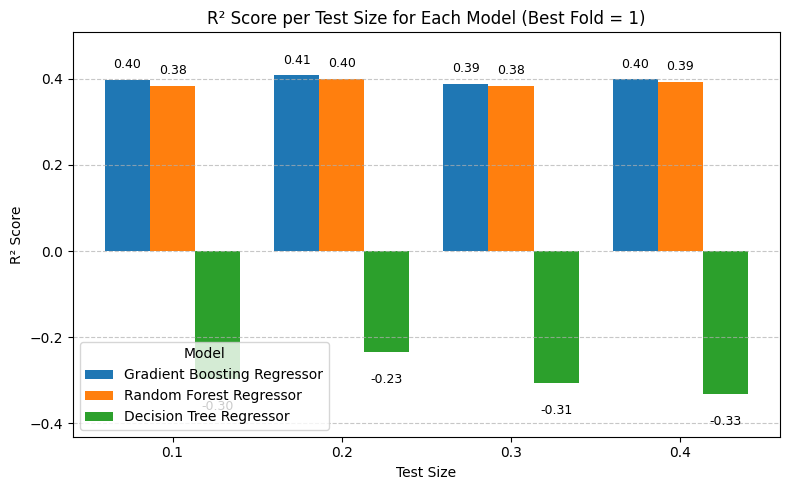

In [119]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Assuming you're working with pandas DataFrames for X

plt.figure(figsize=(8, 5)) # Slightly larger figure for better bar spacing

# Extract unique test sizes and model names
test_sizes = sorted(list(next(iter(hasil_split_train.values())).keys()))
model_names = list(hasil_split_train.keys())

# Set up positions for bars
n_models = len(model_names)
bar_width = 0.8 / n_models # Adjust bar width based on number of models
index = np.arange(len(test_sizes)) # Positions for groups of bars

for i, name in enumerate(model_names):
    r2_scores = [hasil_split_train[name][ts]['r2'] for ts in test_sizes]
    # Calculate position for each model's set of bars
    bar_positions = index + i * bar_width - (n_models - 1) * bar_width / 2

    bars = plt.bar(bar_positions, r2_scores, bar_width, label=name)

    # Add R² value on top of each bar
    for bar in bars:
        yval = bar.get_height()
        # Adjust text position based on whether R2 is positive or negative
        # Add a small offset so text doesn't touch the bar
        plt.text(bar.get_x() + bar.get_width()/2, yval + (0.02 if yval >= 0 else -0.05),
            f'{yval:.2f}', ha='center', va='bottom' if yval >= 0 else 'top', fontsize=9)


plt.title("R² Score per Test Size for Each Model (Best Fold = 1)")
plt.xlabel("Test Size")
plt.ylabel("R² Score")
plt.xticks(index, test_sizes) # Set x-axis ticks to the test sizes
# Adjust y-axis limits to accommodate negative R² and text labels
min_r2 = min(min(metrics['r2'] for metrics in res.values()) for res in hasil_split_train.values())
max_r2 = max(max(metrics['r2'] for metrics in res.values()) for res in hasil_split_train.values())
plt.ylim(min_r2 - 0.1, max_r2 + 0.1) # Add some padding

plt.grid(axis='y', linestyle='--', alpha=0.7) # Only y-axis grid for bar charts
plt.legend(title="Model", loc='best')
plt.tight_layout()
plt.show()

# Uji Test Split Semua Data

In [135]:
hasil_split_train_all = {}

In [147]:
for name, model in models.items():
    hasil_split_train_all[name] = {}
    
    for test_size in test_split_size:
        X_train, X_test, y_train, y_test, sw_train, sw_test = train_test_split(
            X, y, sample_weight, test_size=test_size, random_state=42
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        hasil_split_train_all[name][test_size] = {
            'mse': mse,
            'mae': mae,
            'r2': r2
        }

In [150]:
hasil_split_train_all

{'Gradient Boosting Regressor': {0.1: {'mse': 29.39723460142784,
   'mae': 4.126130098801538,
   'r2': 0.3981193027784523},
  0.2: {'mse': 29.296254668408455,
   'mae': 4.1230759412187545,
   'r2': 0.40277501221984213},
  0.3: {'mse': 29.20318278999798,
   'mae': 4.11991735509763,
   'r2': 0.3952023927694195},
  0.4: {'mse': 29.321869716610365,
   'mae': 4.132986995661615,
   'r2': 0.39827012082347535}},
 'Random Forest Regressor': {0.1: {'mse': 28.07688966414765,
   'mae': 4.010897000937207,
   'r2': 0.4251521220962443},
  0.2: {'mse': 28.18192601817492,
   'mae': 4.022887831559215,
   'r2': 0.4254913942984172},
  0.3: {'mse': 28.210017285894324,
   'mae': 4.028128579398375,
   'r2': 0.4157708398727802},
  0.4: {'mse': 28.544897677368617,
   'mae': 4.053795745464283,
   'r2': 0.4142147824639173}},
 'Decision Tree Regressor': {0.1: {'mse': 59.74134605703575,
   'mae': 5.921985540232963,
   'r2': -0.22314780642720633},
  0.2: {'mse': 60.17317070362188,
   'mae': 5.926167235723372,
   'r

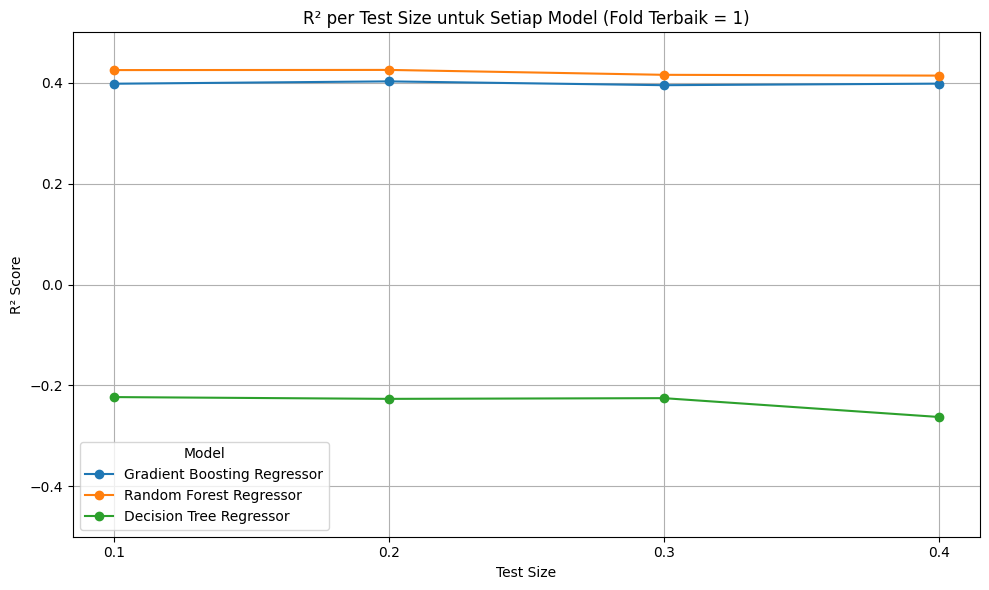

In [149]:
plt.figure(figsize=(10, 6))

# Plot R² untuk setiap model
for name, result in hasil_split_train_all.items():
    test_sizes = sorted(result.keys())
    r2_scores = [result[ts]['r2'] for ts in test_sizes]
    plt.plot(test_sizes, r2_scores, marker='o', label=name)

plt.title("R² per Test Size untuk Setiap Model (Fold Terbaik = 1)")
plt.xlabel("Test Size")
plt.ylabel("R² Score")
plt.xticks(test_sizes)
plt.ylim(-0.5, 0.5)  # sesuaikan sesuai range R² Anda
plt.grid(True)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


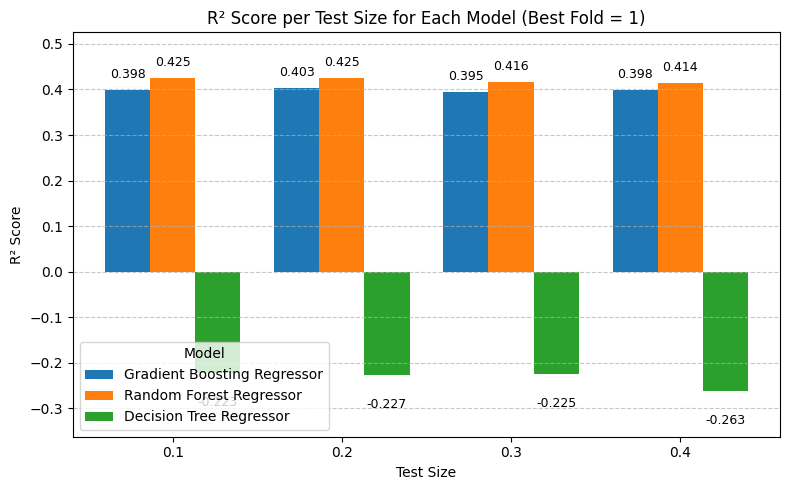

In [148]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Assuming you're working with pandas DataFrames for X

plt.figure(figsize=(8, 5)) # Slightly larger figure for better bar spacing

# Extract unique test sizes and model names
test_sizes = sorted(list(next(iter(hasil_split_train_all.values())).keys()))
model_names = list(hasil_split_train_all.keys())

# Set up positions for bars
n_models = len(model_names)
bar_width = 0.8 / n_models # Adjust bar width based on number of models
index = np.arange(len(test_sizes)) # Positions for groups of bars

for i, name in enumerate(model_names):
    r2_scores = [hasil_split_train_all[name][ts]['r2'] for ts in test_sizes]
    # Calculate position for each model's set of bars
    bar_positions = index + i * bar_width - (n_models - 1) * bar_width / 2

    bars = plt.bar(bar_positions, r2_scores, bar_width, label=name)

    # Add R² value on top of each bar
    for bar in bars:
        yval = bar.get_height()
        # Adjust text position based on whether R2 is positive or negative
        # Add a small offset so text doesn't touch the bar
        plt.text(bar.get_x() + bar.get_width()/2, yval + (0.02 if yval >= 0 else -0.05),
            f'{yval:.3f}', ha='center', va='bottom' if yval >= 0 else 'top', fontsize=9)


plt.title("R² Score per Test Size for Each Model (Best Fold = 1)")
plt.xlabel("Test Size")
plt.ylabel("R² Score")
plt.xticks(index, test_sizes) # Set x-axis ticks to the test sizes
# Adjust y-axis limits to accommodate negative R² and text labels
min_r2 = min(min(metrics['r2'] for metrics in res.values()) for res in hasil_split_train_all.values())
max_r2 = max(max(metrics['r2'] for metrics in res.values()) for res in hasil_split_train_all.values())
plt.ylim(min_r2 - 0.1, max_r2 + 0.1) # Add some padding

plt.grid(axis='y', linestyle='--', alpha=0.7) # Only y-axis grid for bar charts
plt.legend(title="Model", loc='best')
plt.tight_layout()
plt.show()

# Hyperparamater Tunning

In [178]:
X_train, X_test, y_train, y_test, sw_train, sw_test = train_test_split(
	X_best_fold, y_best_fold, sw_best_fold, test_size=0.2, random_state=42
)


In [194]:
X_train_gbr, X_test_gbr, y_train_gbr, y_test_gbr, sw_train_gbr, sw_test_gbr = train_test_split(
	X_best_fold_gbr, y_best_fold_gbr, sw_best_fold_gbr, test_size=0.2, random_state=42
)

In [ ]:
# Fungsi objektif untuk PSO
def objective_function(params):
    results = []
    for p in params:
        n_estimators = int(p[0])
        max_depth = int(p[1])

        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            n_jobs=-1,
            random_state=42
        )
        score = cross_val_score(model, X_train, y_train, cv=3, scoring='r2', n_jobs=-1).mean()
        results.append(score)  # minimisasi R2
    return np.array(results)

In [ ]:
# Fungsi objektif untuk PSO
def objective_function_gbr(params):
    results = []
    for p in params:
        n_estimators = int(p[0])
        max_depth = int(p[1])
        learning_rate = p[2]

        model = GradientBoostingRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
			learning_rate=learning_rate,
            random_state=42
        )
        score = cross_val_score(model, X_train_gbr, y_train_gbr, cv=3, scoring='r2', n_jobs=-1).mean()
        results.append(score)  # minimisasi R2
    return np.array(results)

In [ ]:
# Batas parameter
# [n_estimators, max_depth, learning_rate]
bounds = ([100, 10], [300, 30])

# Inisialisasi optimizer
optimizer = ps.single.GlobalBestPSO(
    n_particles=5,
    dimensions=2,
    options={'c1': 1.5, 'c2': 1.5, 'w': 0.5},
    bounds=bounds
)

In [191]:
# Batas parameter
# [n_estimators, max_depth, learning_rate]
bounds_gbr = ([100, 10, 0.1], [300, 30, 0.5])

# Inisialisasi optimizer
optimizer_gbr = ps.single.GlobalBestPSO(
    n_particles=5,
    dimensions=3,
    options={'c1': 1.5, 'c2': 1.5, 'w': 0.5},
    bounds=bounds_gbr
)

In [ ]:
best_cost, best_pos = optimizer.optimize(objective_function, iters=20)

2025-07-09 21:42:56,537 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best:   0%|          |0/20


KeyboardInterrupt: 

In [195]:
best_cost_gbr, best_pos_gbr = optimizer_gbr.optimize(objective_function_gbr, iters=20)

2025-07-09 21:43:31,327 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best:   0%|          |0/20


KeyboardInterrupt: 

In [168]:
# Hasil terbaik
print("Best parameters found by PSO:")
print(f"n_estimators: {int(best_pos[0])}")
print(f"max_depth: {int(best_pos[1])}")
print(f"Best R2: {best_cost:.4f}")

Best parameters found by PSO:
n_estimators: 230
max_depth: 22
Best R2: -0.3778


In [ ]:
# Hasil terbaik GBR
print("Best parameters found by PSO GBR:")
print(f"n_estimators: {int(best_pos_gbr[0])}")
print(f"max_depth: {int(best_pos_gbr[1])}")
print(f"learning_rate: {int(best_pos_gbr[2])}")
print(f"Best R2: {best_cost_gbr:.4f}")

In [183]:
final_rfr = RandomForestRegressor(
    n_estimators=int(best_pos[0]),
    max_depth=int(best_pos[1]),
    random_state=42,
    n_jobs=-1
)
final_rfr.fit(X_train, y_train)
# Prediksi di training dan testing
y_pred_rfr = final_rfr.predict(X_test)

# Evaluasi
r2_rfr = r2_score(y_test, y_pred_rfr)
mse_rfr = mean_squared_error(y_test, y_pred_rfr)
rmse_rfr = np.sqrt(mse_rfr)
mae_rfr = mean_absolute_error(y_test, y_pred_rfr)

# Tampilkan hasil optimasi pso
print(f"R² Score : {r2_rfr:.4f}")
print(f"MSE      : {mse_rfr:.4f}")
print(f"RMSE     : {rmse_rfr:.4f}")
print(f"MAE      : {mae_rfr:.4f}")


R² Score : 0.4007
MSE      : 30.9239
RMSE     : 5.5609
MAE      : 4.1996


In [ ]:
final_gbr = GradientBoostingRegressor(
    n_estimators=int(best_pos[0]),
    max_depth=int(best_pos[1]),
    learning_rate=(best_pos[2]),
    random_state=42,
)
final_gbr.fit(X_train, y_train)
# Prediksi di training dan testing
y_pred_gbr = final_gbr.predict(X_test)

# Evaluasi
r2_gbr = r2_score(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

# Tampilkan hasil optimasi pso GBR
print("hasil optimasi pso GBR")
print(f"R² Score : {r2_gbr:.4f}")
print(f"MSE      : {mse_gbr:.4f}")
print(f"RMSE     : {rmse_gbr:.4f}")
print(f"MAE      : {mae_gbr:.4f}")


In [ ]:
final_rfr_b = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)
final_rfr_b.fit(X_train, y_train)
# Prediksi di training dan testing
y_pred_rfr_b = final_rfr_b.predict(X_test)

# Evaluasi
r2_rfr_b = r2_score(y_test, y_pred_rfr_b)
mse_rfr_b = mean_squared_error(y_test, y_pred_rfr_b)
rmse_rfr_b = np.sqrt(mse_rfr_b)
mae_rfr_b = mean_absolute_error(y_test, y_pred_rfr_b)

# Tampilkan hasil tanpa optimasi pso
print(f"R² Score : {r2_rfr_b:.4f}")
print(f"MSE      : {mse_rfr_b:.4f}")
print(f"RMSE     : {rmse_rfr_b:.4f}")
print(f"MAE      : {mae_rfr_b:.4f}")


R² Score : 0.3992
MSE      : 31.0001
RMSE     : 5.5678
MAE      : 4.2084


In [ ]:
final_gbr_b = GradientBoostingRegressor(
    random_state=42,
)
final_gbr_b.fit(X_train, y_train)
# Prediksi di training dan testing
y_pred_gbr_b = final_gbr_b.predict(X_test)

# Evaluasi
r2_gbr_b = r2_score(y_test, y_pred_gbr_b)
mse_gbr_b = mean_squared_error(y_test, y_pred_gbr_b)
rmse_gbr_b = np.sqrt(mse_gbr_b)
mae_gbr_b = mean_absolute_error(y_test, y_pred_gbr_b)

# Tampilkan hasil optimasi pso GBR
print("hasil tanpa optimasi pso GBR")
print(f"R² Score : {r2_gbr_b:.4f}")
print(f"MSE      : {mse_gbr_b:.4f}")
print(f"RMSE     : {rmse_gbr_b:.4f}")
print(f"MAE      : {mae_gbr_b:.4f}")


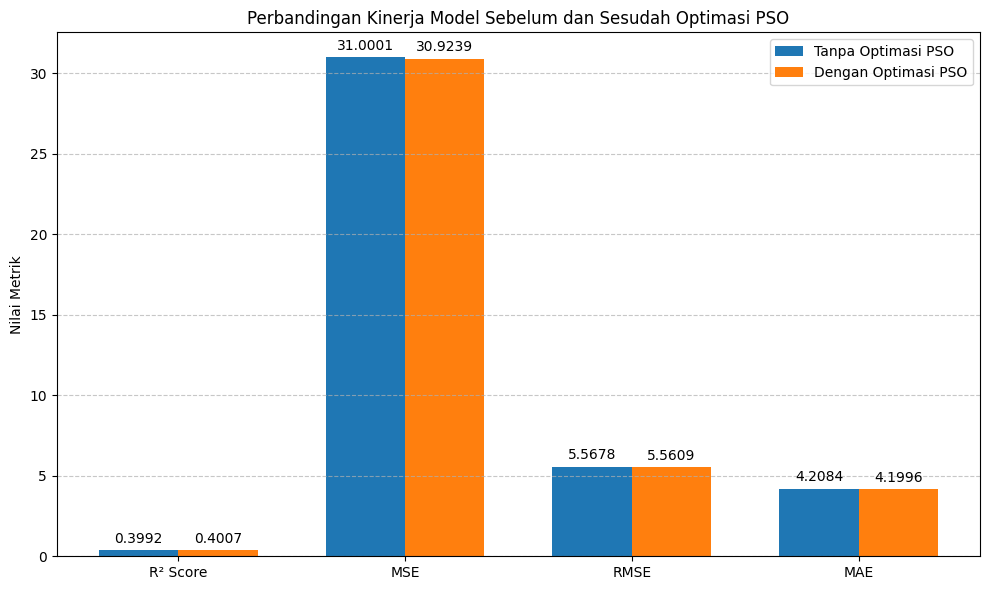

In [184]:
# Metrics labels
labels = ['R² Score', 'MSE', 'RMSE', 'MAE']

# Values for non-optimized and PSO-optimized models
non_optimized_values = [r2_rfr_b, mse_rfr_b, rmse_rfr_b, mae_rfr_b]
pso_optimized_values = [r2_rfr, mse_rfr, rmse_rfr, mae_rfr]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, non_optimized_values, width, label='Tanpa Optimasi PSO')
rects2 = ax.bar(x + width/2, pso_optimized_values, width, label='Dengan Optimasi PSO')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Nilai Metrik')
ax.set_title('Perbandingan Kinerja Model Sebelum dan Sesudah Optimasi PSO')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Function to add value labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

# TEST

In [173]:
X_train_cek, X_test_cek, y_train_cek, y_test_cek, sw_train_cek, sw_test_cek = train_test_split(
	X, y, sample_weight, test_size=0.2, random_state=42
)


In [174]:
rfr.fit(X_train_cek, y_train_cek)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [175]:
y_pred = rfr.predict(X_test_cek)

mse = mean_squared_error(y_test_cek, y_pred)
mae = mean_absolute_error(y_test_cek, y_pred)
r2 = r2_score(y_test_cek, y_pred)

In [176]:
print(mse)
print(mae)
print(r2)

28.18192601817492
4.022887831559215
0.4254913942984172
